Notebook 02 : Preprocessing et Feature Engineering

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
import joblib
import json
import warnings

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)

print("✅ Bibliothèques importées avec succès!")

✅ Bibliothèques importées avec succès!


In [20]:
df = pd.read_csv('../data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv')

print(f"📊 Dataset chargé : {df.shape[0]} lignes × {df.shape[1]} colonnes")
print(f"\n🔍 Aperçu des premières lignes :")
print(df.head(3))

# Créer une copie pour le preprocessing
df_clean = df.copy()

📊 Dataset chargé : 7043 lignes × 21 colonnes

🔍 Aperçu des premières lignes :
   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity OnlineBackup  \
0  No phone service             DSL             No          Yes   
1                No             DSL            Yes           No   
2                No             DSL            Yes          Yes   

  DeviceProtection TechSupport StreamingTV StreamingMovies        Contract  \
0               No          No          No              No  Month-to-month   
1              Yes          No          No              No        One year   
2               No          No          No              No  Month-to-month   

  PaperlessBilling 

NETTOYAGE DES DONNÉES

In [21]:
print("\n🧹 NETTOYAGE DES DONNÉES")
print("="*80)

# 3.1 - Gestion de la colonne customerID
# Cette colonne est un identifiant unique, elle n'apporte rien au modèle
if 'customerID' in df_clean.columns:
    df_clean = df_clean.drop('customerID', axis=1)
    print("✅ Colonne 'customerID' supprimée.")



🧹 NETTOYAGE DES DONNÉES
✅ Colonne 'customerID' supprimée.


In [22]:
# 3.2 - Conversion de TotalCharges en numérique
# Souvent cette colonne contient des espaces vides au lieu de 0
print("\n🔧 Traitement de la colonne 'TotalCharges'...")

# Remplacer les virgules par des points (format européen)
df_clean['TotalCharges'] = df_clean['TotalCharges'].str.replace(',', '.', regex=False)

# Supprimer les espaces et caractères non numériques
df_clean['TotalCharges'] = df_clean['TotalCharges'].str.replace(r'[^\d.]', '', regex=True)

# Convertir en float
df_clean['TotalCharges'] = pd.to_numeric(df_clean['TotalCharges'], errors='coerce')



🔧 Traitement de la colonne 'TotalCharges'...


In [23]:
# 3.3 - Gestion des valeurs manquantes
print("\n🔍 Suppression des valeurs manquantes...")

df_clean= df_clean.dropna(subset=['TotalCharges'])

print(f"\n📊 Dataset nettoyé : {df_clean.shape[0]} lignes × {df_clean.shape[1]} colonnes")



🔍 Suppression des valeurs manquantes...

📊 Dataset nettoyé : 7032 lignes × 20 colonnes


FEATURE ENGINEERING (CRÉATION DE NOUVELLES VARIABLES)

In [24]:
print("\n🔧 FEATURE ENGINEERING")
print("="*80)

# 4.1 - Revenus moyens par mois
if 'TotalCharges' in df_clean.columns and 'tenure' in df_clean.columns:
    # Éviter la division par zéro
    df_clean['AvgMonthlyCharges'] = df_clean.apply(
        lambda row: row['TotalCharges'] / row['tenure'] if row['tenure'] > 0 else row['MonthlyCharges'],
        axis=1
    )
    print("✅ Nouvelle variable : 'AvgMonthlyCharges' (revenus moyens mensuels)")

# 4.2 - Catégorie d'ancienneté
if 'tenure' in df_clean.columns:
    df_clean['TenureCategory'] = pd.cut(
        df_clean['tenure'],
        bins=[0, 12, 24, 48, 72],
        labels=['0-1 an', '1-2 ans', '2-4 ans', '4+ ans']
    )
    print("✅ Nouvelle variable : 'TenureCategory' (catégorie d'ancienneté)")



🔧 FEATURE ENGINEERING
✅ Nouvelle variable : 'AvgMonthlyCharges' (revenus moyens mensuels)
✅ Nouvelle variable : 'TenureCategory' (catégorie d'ancienneté)


In [25]:
# 4.3 - Nombre total de services souscrits
service_cols = ['PhoneService', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
                'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']

# Vérifier quelles colonnes existent
existing_service_cols = [col for col in service_cols if col in df_clean.columns]

if existing_service_cols:
    df_clean['TotalServices'] = 0
    for col in existing_service_cols:
        # Compter comme service si != 'No' et != 'No internet service' et != 'No phone service'
        df_clean['TotalServices'] += (~df_clean[col].isin(['No', 'No internet service', 'No phone service'])).astype(int)
    
    print(f"✅ Nouvelle variable : 'TotalServices' (nombre de services souscrits)")
    print(f"   Distribution : Min={df_clean['TotalServices'].min()}, Max={df_clean['TotalServices'].max()}, Moyenne={df_clean['TotalServices'].mean():.2f}")


✅ Nouvelle variable : 'TotalServices' (nombre de services souscrits)
   Distribution : Min=1, Max=8, Moyenne=3.73


In [26]:
# 4.4 - Ratio MonthlyCharges / TotalServices
if 'TotalServices' in df_clean.columns and 'MonthlyCharges' in df_clean.columns:
    df_clean['ChargesPerService'] = df_clean.apply(
        lambda row: row['MonthlyCharges'] / row['TotalServices'] if row['TotalServices'] > 0 else row['MonthlyCharges'],
        axis=1
    )
    print("✅ Nouvelle variable : 'ChargesPerService' (coût par service)")


✅ Nouvelle variable : 'ChargesPerService' (coût par service)


In [27]:
# 4.5 - Client senior avec famille
if 'SeniorCitizen' in df_clean.columns and 'Partner' in df_clean.columns:
    df_clean['SeniorWithFamily'] = ((df_clean['SeniorCitizen'] == 1) & 
                                     (df_clean['Partner'] == 'Yes')).astype(int)
    print("✅ Nouvelle variable : 'SeniorWithFamily' (senior avec partenaire)")

print(f"\n📊 Dataset enrichi : {df_clean.shape[0]} lignes × {df_clean.shape[1]} colonnes")


✅ Nouvelle variable : 'SeniorWithFamily' (senior avec partenaire)

📊 Dataset enrichi : 7032 lignes × 25 colonnes


ENCODAGE DES VARIABLES CATÉGORIELLES

In [28]:
print("\n🔢 ENCODAGE DES VARIABLES CATÉGORIELLES")
print("="*80)

# Séparer les variables catégorielles et numériques
categorical_cols = df_clean.select_dtypes(include=['object', 'category']).columns.tolist()
if 'Churn' in categorical_cols:
    categorical_cols.remove('Churn')  # On traite Churn séparément

print(f"\n📋 Variables catégorielles à encoder : {len(categorical_cols)}")
print(categorical_cols)


🔢 ENCODAGE DES VARIABLES CATÉGORIELLES

📋 Variables catégorielles à encoder : 16
['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'TenureCategory']


In [29]:
# 5.1 - Variables binaires (2 valeurs) → Label Encoding
binary_cols = []
for col in categorical_cols:
    unique_values = df_clean[col].nunique()
    if unique_values == 2:
        binary_cols.append(col)

print(f"\n✏️ Label Encoding pour {len(binary_cols)} variables binaires...")
for col in binary_cols:
    le = LabelEncoder()
    df_clean[col] = le.fit_transform(df_clean[col])
    print(f"   ✅ {col}: {list(le.classes_)} → {list(range(len(le.classes_)))}")



✏️ Label Encoding pour 5 variables binaires...
   ✅ gender: ['Female', 'Male'] → [0, 1]
   ✅ Partner: ['No', 'Yes'] → [0, 1]
   ✅ Dependents: ['No', 'Yes'] → [0, 1]
   ✅ PhoneService: ['No', 'Yes'] → [0, 1]
   ✅ PaperlessBilling: ['No', 'Yes'] → [0, 1]


In [30]:
# 5.2 - Variables multi-catégories → One-Hot Encoding
multi_category_cols = [col for col in categorical_cols if col not in binary_cols]

if multi_category_cols:
    print(f"\n🔄 One-Hot Encoding pour {len(multi_category_cols)} variables multi-catégories...")
    df_clean = pd.get_dummies(df_clean, columns=multi_category_cols, drop_first=True)
    print(f"   ✅ Nouvelles colonnes créées")



🔄 One-Hot Encoding pour 11 variables multi-catégories...
   ✅ Nouvelles colonnes créées


In [31]:
# 5.3 - Encoder la variable cible (Churn)
print(f"\n🎯 Encodage de la variable cible 'Churn'...")
df_clean['Churn'] = (df_clean['Churn'] == 'Yes').astype(int)
print("   ✅ Churn: No=0, Yes=1")

print(f"\n📊 Dataset après encodage : {df_clean.shape[0]} lignes × {df_clean.shape[1]} colonnes")



🎯 Encodage de la variable cible 'Churn'...
   ✅ Churn: No=0, Yes=1

📊 Dataset après encodage : 7032 lignes × 38 colonnes


SÉPARATION FEATURES / TARGET

In [33]:
print("\n✂️ SÉPARATION FEATURES / TARGET")
print("="*80)

# Variables explicatives (features)
X = df_clean.drop('Churn', axis=1)

# Variable cible (target)
y = df_clean['Churn']

print(f"✅ Features (X) : {X.shape[1]} colonnes")
print(f"✅ Target (y) : {y.shape[0]} lignes")
print(f"\n📊 Distribution du target :")
print(f"   - Churn = 0 (No)  : {(y==0).sum()} ({(y==0).sum()/len(y)*100:.2f}%)")
print(f"   - Churn = 1 (Yes) : {(y==1).sum()} ({(y==1).sum()/len(y)*100:.2f}%)")



✂️ SÉPARATION FEATURES / TARGET
✅ Features (X) : 37 colonnes
✅ Target (y) : 7032 lignes

📊 Distribution du target :
   - Churn = 0 (No)  : 5163 (73.42%)
   - Churn = 1 (Yes) : 1869 (26.58%)


SPLIT TRAIN / TEST

In [34]:
print("\n📊 SPLIT TRAIN / TEST")
print("="*80)

# Split avec stratification (pour garder la même proportion de churn)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,      # 20% pour le test
    random_state=42,    # Pour la reproductibilité
    stratify=y          # Garder la même proportion de churn
)

print(f"✅ Train set : {X_train.shape[0]} lignes ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"   - Churn = 0 : {(y_train==0).sum()} ({(y_train==0).sum()/len(y_train)*100:.2f}%)")
print(f"   - Churn = 1 : {(y_train==1).sum()} ({(y_train==1).sum()/len(y_train)*100:.2f}%)")

print(f"\n✅ Test set  : {X_test.shape[0]} lignes ({X_test.shape[0]/len(X)*100:.1f}%)")
print(f"   - Churn = 0 : {(y_test==0).sum()} ({(y_test==0).sum()/len(y_test)*100:.2f}%)")
print(f"   - Churn = 1 : {(y_test==1).sum()} ({(y_test==1).sum()/len(y_test)*100:.2f}%)")



📊 SPLIT TRAIN / TEST
✅ Train set : 5625 lignes (80.0%)
   - Churn = 0 : 4130 (73.42%)
   - Churn = 1 : 1495 (26.58%)

✅ Test set  : 1407 lignes (20.0%)
   - Churn = 0 : 1033 (73.42%)
   - Churn = 1 : 374 (26.58%)


NORMALISATION DES DONNÉES

In [35]:
print("\n📏 NORMALISATION (STANDARDISATION)")
print("="*80)

# Créer le scaler
scaler = StandardScaler()

# Fit sur le train UNIQUEMENT (pour éviter le data leakage)
scaler.fit(X_train)

# Transform train et test
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Reconvertir en DataFrame pour garder les noms de colonnes
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

print("✅ Normalisation effectuée avec StandardScaler")
print(f"\n📊 Exemple de transformation (première variable : {X_train.columns[0]}):")
print(f"   Avant : mean={X_train.iloc[:, 0].mean():.2f}, std={X_train.iloc[:, 0].std():.2f}")
print(f"   Après : mean={X_train_scaled.iloc[:, 0].mean():.2f}, std={X_train_scaled.iloc[:, 0].std():.2f}")



📏 NORMALISATION (STANDARDISATION)
✅ Normalisation effectuée avec StandardScaler

📊 Exemple de transformation (première variable : gender):
   Avant : mean=0.50, std=0.50
   Après : mean=-0.00, std=1.00


STRATÉGIE POUR GÉRER LE DÉSÉQUILIBRE

In [36]:
print("\n⚖️ STRATÉGIE POUR GÉRER LE DÉSÉQUILIBRE")
print("="*80)

# Calculer les poids des classes
churn_ratio = (y_train==1).sum() / len(y_train)
print(f"📊 Ratio de churn dans le train : {churn_ratio*100:.2f}%")

# Calculer class_weight
from sklearn.utils.class_weight import compute_class_weight

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)

class_weight_dict = {0: class_weights[0], 1: class_weights[1]}

print(f"\n✅ Class weights calculés :")
print(f"   - Classe 0 (No Churn) : poids = {class_weight_dict[0]:.2f}")
print(f"   - Classe 1 (Churn)    : poids = {class_weight_dict[1]:.2f}")



⚖️ STRATÉGIE POUR GÉRER LE DÉSÉQUILIBRE
📊 Ratio de churn dans le train : 26.58%

✅ Class weights calculés :
   - Classe 0 (No Churn) : poids = 0.68
   - Classe 1 (Churn)    : poids = 1.88


In [ ]:
print(f"\n💡 STRATÉGIE ADOPTÉE :")
print(f"""
   1. ✅ Utiliser 'class_weight=balanced' dans les modèles
       Donne plus d'importance aux exemples de la classe minoritaire
      
   2. ✅ Privilégier les métriques adaptées :
       Accuracy : Mauvaise métrique pour données déséquilibrées
       Recall (capturer le maximum de vrais churns)
       F1-Score (équilibre Precision/Recall)
       AUC-ROC (performance globale)
      
   3. ✅ Ajuster le seuil de décision si nécessaire
       Par défaut : probabilité > 0.5 = Churn
       On pourra baisser à 0.3-0.4 pour capturer plus de churns
      
   4. ✅ Garder les données originales
       Plus représentatif de la réalité
       Pas de sur-apprentissage sur données synthétiques
""")


💡 STRATÉGIE ADOPTÉE :

   1. ✅ Utiliser 'class_weight=balanced' dans les modèles
      → Donne plus d'importance aux exemples de la classe minoritaire

   2. ✅ Privilégier les métriques adaptées :
      → Recall (capturer le maximum de vrais churns)
      → F1-Score (équilibre Precision/Recall)
      → AUC-ROC (performance globale)

   3. ✅ Ajuster le seuil de décision si nécessaire
      → Par défaut : probabilité > 0.5 = Churn
      → On pourra baisser à 0.3-0.4 pour capturer plus de churns

   4. ✅ Garder les données originales
      → Plus représentatif de la réalité
      → Pas de sur-apprentissage sur données synthétiques



In [38]:
# Sauvegarder les class weights pour utilisation future
class_weight_info = {
    'class_weight_dict': class_weight_dict,
    'churn_ratio': float(churn_ratio),
    'strategy': 'class_weight_balanced'
}


SAUVEGARDE DES DONNÉES TRAITÉES

In [39]:
print("\n💾 SAUVEGARDE DES DONNÉES TRAITÉES")
print("="*80)

# Créer un dictionnaire avec toutes les données
processed_data = {
    'X_train': X_train_scaled,
    'X_test': X_test_scaled,
    'y_train': y_train,
    'y_test': y_test,
    'feature_names': list(X_train.columns),
    'scaler': scaler,
    'class_weight_dict': class_weight_dict
}

# Sauvegarder avec joblib
joblib.dump(processed_data, '../data/processed/processed_data.pkl')
print("✅ Données sauvegardées : data/processed/processed_data.pkl")

# Sauvegarder aussi le scaler séparément (pour l'API)
joblib.dump(scaler, '../data/processed/scaler.pkl')
print("✅ Scaler sauvegardé : data/processed/scaler.pkl")


💾 SAUVEGARDE DES DONNÉES TRAITÉES
✅ Données sauvegardées : data/processed/processed_data.pkl
✅ Scaler sauvegardé : data/processed/scaler.pkl


In [40]:
# Sauvegarder les noms de colonnes
with open('../data/processed/feature_names.json', 'w') as f:
    json.dump(list(X_train.columns), f, indent=4)
print("✅ Noms des features sauvegardés : data/processed/feature_names.json")

# Sauvegarder les class weights
with open('../data/processed/class_weights.json', 'w') as f:
    json.dump(class_weight_info, f, indent=4)
print("✅ Class weights sauvegardés : data/processed/class_weights.json")


✅ Noms des features sauvegardés : data/processed/feature_names.json
✅ Class weights sauvegardés : data/processed/class_weights.json


In [41]:
# Statistiques finales
preprocessing_stats = {
    'original_shape': df.shape,
    'cleaned_shape': df_clean.shape,
    'n_features': X_train.shape[1],
    'train_size': len(X_train_scaled),
    'test_size': len(X_test_scaled),
    'churn_rate_original': float((y==1).sum() / len(y)),
    'churn_rate_train': float((y_train==1).sum() / len(y_train)),
    'churn_rate_test': float((y_test==1).sum() / len(y_test)),
    'features_created': ['AvgMonthlyCharges', 'TenureCategory', 'TotalServices', 
                         'ChargesPerService', 'SeniorWithFamily'],
    'balancing_strategy': 'class_weight_balanced',
    'class_weights': class_weight_dict
}

with open('../data/processed/preprocessing_stats.json', 'w') as f:
    json.dump(preprocessing_stats, f, indent=4)
print("✅ Statistiques sauvegardées : data/processed/preprocessing_stats.json")


✅ Statistiques sauvegardées : data/processed/preprocessing_stats.json


VISUALISATION FINALE


📊 VISUALISATION DE LA DISTRIBUTION


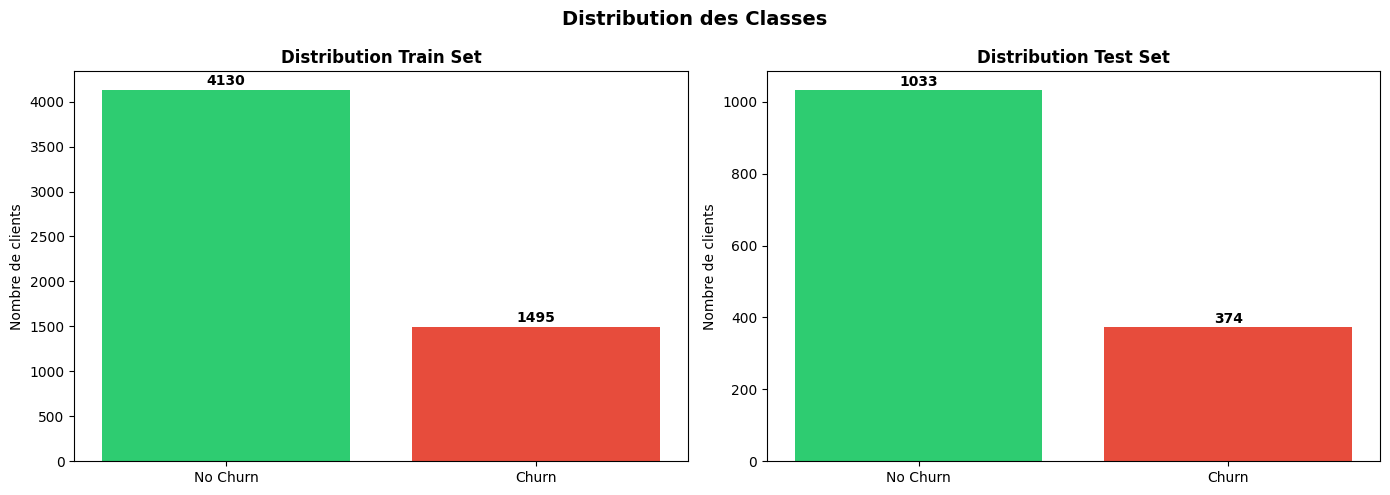

In [43]:
print("\n📊 VISUALISATION DE LA DISTRIBUTION")
print("="*80)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution Train
axes[0].bar(['No Churn', 'Churn'], [(y_train==0).sum(), (y_train==1).sum()], 
            color=['#2ecc71', '#e74c3c'])
axes[0].set_title('Distribution Train Set', fontweight='bold', fontsize=12)
axes[0].set_ylabel('Nombre de clients')
for i, v in enumerate([(y_train==0).sum(), (y_train==1).sum()]):
    axes[0].text(i, v + 50, str(v), ha='center', fontweight='bold')

# Distribution Test
axes[1].bar(['No Churn', 'Churn'], [(y_test==0).sum(), (y_test==1).sum()], 
            color=['#2ecc71', '#e74c3c'])
axes[1].set_title('Distribution Test Set', fontweight='bold', fontsize=12)
axes[1].set_ylabel('Nombre de clients')
for i, v in enumerate([(y_test==0).sum(), (y_test==1).sum()]):
    axes[1].text(i, v + 10, str(v), ha='center', fontweight='bold')

plt.suptitle('Distribution des Classes', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [44]:
print("="*80)
print("""
📝 RÉCAPITULATIF :
  ✅ Données nettoyées (valeurs manquantes traitées)
  ✅ 5 nouvelles features créées
  ✅ Variables catégorielles encodées
  ✅ Données normalisées (StandardScaler)
  ✅ Dataset NON rééchantillonné (données originales conservées)
  ✅ Class weights calculés pour compenser le déséquilibre
  ✅ Split train/test effectué (80/20)
  ✅ Toutes les données sauvegardées

⚖️ STRATÉGIE DE DÉSÉQUILIBRE :
  → Utilisation de 'class_weight=balanced' dans les modèles
  → Métriques adaptées : Recall, F1-Score, AUC-ROC
  → Possibilité d'ajuster le seuil de décision

""")


📝 RÉCAPITULATIF :
  ✅ Données nettoyées (valeurs manquantes traitées)
  ✅ 5 nouvelles features créées
  ✅ Variables catégorielles encodées
  ✅ Données normalisées (StandardScaler)
  ✅ Dataset NON rééchantillonné (données originales conservées)
  ✅ Class weights calculés pour compenser le déséquilibre
  ✅ Split train/test effectué (80/20)
  ✅ Toutes les données sauvegardées

⚖️ STRATÉGIE DE DÉSÉQUILIBRE :
  → Utilisation de 'class_weight=balanced' dans les modèles
  → Métriques adaptées : Recall, F1-Score, AUC-ROC
  → Possibilité d'ajuster le seuil de décision


